# Segmentators Testing — Phone-Deployable Models

Benchmarks **3 Cityscapes semantic segmentation models** that detect `road` and `sidewalk` and can run on-device via ONNX / TFLite.
All latencies measured on CPU.

| Model | Backbone | Dataset | Params | mIoU | Phone? |
|---|---|---|---|---|---|
| **SegFormer-B0** | Mix Transformer B0 | Cityscapes 19-cls | 3.7 M | 76.2 | ✓ |
| **SegFormer-B1** | Mix Transformer B1 | Cityscapes 19-cls | 13.7 M | 78.5 | ~ |
| **DeepLabV3+ MobileNetV2** | MobileNetV2 | Cityscapes 19-cls | 5.8 M | 72.0 | ✓ |

> **Phone deployment path:** ONNX → `onnx2tf` → `.tflite` → `react-native-fast-tflite`

## 1. Install dependencies

In [8]:
# %pip install transformers torch torchvision numpy Pillow matplotlib tqdm --quiet

## 2. Imports & config

In [ ]:
import os, time, subprocess, sys
import numpy as np
import torch
import requests
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

INPUT_DIR  = '../../../../datasets/testing'
OUTPUT_DIR = '../../../../datasets/testing_results_segmentators'
MODEL_DIR  = '../models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('PyTorch:', torch.__version__)
print('Device :', DEVICE)
print('Input  :', INPUT_DIR)

PyTorch: 2.12.1+cpu
Device : cpu
Input  : ../../../../datasets/testing


: 

## 3. Class definitions & color palettes

In [10]:
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence',
    'pole', 'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck',
    'bus', 'train', 'motorcycle', 'bicycle',
]
CITYSCAPES_COLORS = np.array([
    [128,  64, 128], [244,  35, 232], [ 70,  70,  70], [102, 102, 156],
    [190, 153, 153], [153, 153, 153], [250, 170,  30], [220, 220,   0],
    [107, 142,  35], [152, 251, 152], [ 70, 130, 180], [220,  20,  60],
    [255,   0,   0], [  0,   0, 142], [  0,   0,  70], [  0,  60, 100],
    [  0,  80, 100], [  0,   0, 230], [119,  11,  32],
], dtype=np.uint8)
CS_PATH_IDS = {0, 1}                      # road, sidewalk
CS_OBS_IDS  = {11,12,13,14,15,17,18}     # person,rider,car,truck,bus,motorcycle,bicycle

print('Path classes    :', {CITYSCAPES_CLASSES[i] for i in CS_PATH_IDS})
print('Obstacle classes:', {CITYSCAPES_CLASSES[i] for i in CS_OBS_IDS})

Path classes    : {'road', 'sidewalk'}
Obstacle classes: {'person', 'bicycle', 'rider', 'motorcycle', 'bus', 'car', 'truck'}


## 4. Shared visualization helpers

In [11]:
def colorize(seg_map: np.ndarray, colors: np.ndarray) -> np.ndarray:
    return colors[np.clip(seg_map, 0, len(colors) - 1)]


def make_overlay(orig: Image.Image, seg_map: np.ndarray, colors: np.ndarray,
                 alpha: float = 0.55) -> np.ndarray:
    h, w = seg_map.shape
    orig_np = np.array(orig.resize((w, h)))
    blend = orig_np.astype(np.float32) * (1 - alpha) + colorize(seg_map, colors).astype(np.float32) * alpha
    return blend.clip(0, 255).astype(np.uint8)


def make_path_mask(seg_map: np.ndarray, path_ids: set) -> np.ndarray:
    return np.isin(seg_map, list(path_ids)).astype(np.uint8) * 255 if path_ids else np.zeros_like(seg_map, dtype=np.uint8)


def make_obs_mask(seg_map: np.ndarray, obs_ids: set) -> np.ndarray:
    return np.isin(seg_map, list(obs_ids)).astype(np.uint8) * 255

## 5. Model registry & loaders

In [12]:
def _load_segformer(model_id: str):
    processor = AutoImageProcessor.from_pretrained(model_id)
    m = AutoModelForSemanticSegmentation.from_pretrained(model_id).to(DEVICE).eval()
    size_mb = sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6

    def infer(pil_img: Image.Image) -> np.ndarray:
        inputs = processor(images=pil_img, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = m(**inputs)
        return processor.post_process_semantic_segmentation(
            out, target_sizes=[pil_img.size[::-1]]
        )[0].cpu().numpy().astype(np.uint8)

    return size_mb, infer


def _load_vainf_deeplabv3plus():
    # Clone VainF/DeepLabV3Plus-Pytorch if not present (no PyPI package)
    vainf_dir = os.path.join(MODEL_DIR, 'DeepLabV3Plus-Pytorch')
    if not os.path.exists(vainf_dir):
        print('  Cloning VainF/DeepLabV3Plus-Pytorch...')
        subprocess.run(
            ['git', 'clone', '--depth', '1',
             'https://github.com/VainF/DeepLabV3Plus-Pytorch.git', vainf_dir],
            check=True, capture_output=True,
        )
    if vainf_dir not in sys.path:
        sys.path.insert(0, vainf_dir)
    import network  # noqa: PLC0415 — local import after path setup

    # Download Cityscapes MobileNetV2 checkpoint from Dropbox (dl=1 = direct)
    ckpt_path = os.path.join(MODEL_DIR, 'deeplabv3plus_mobilenet_cityscapes.pth')
    if not os.path.exists(ckpt_path):
        print('  Downloading checkpoint from Dropbox...')
        url = 'https://www.dropbox.com/s/753ojyvsh3vdjol/best_deeplabv3plus_mobilenet_cityscapes_os16.pth?dl=1'
        r = requests.get(url, stream=True, headers={'User-Agent': 'Mozilla/5.0'})
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(ckpt_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc='ckpt') as bar:
            for chunk in r.iter_content(65536):
                f.write(chunk); bar.update(len(chunk))

    # Build model (pretrained_backbone=False — full weights come from checkpoint)
    m = network.modeling.deeplabv3plus_mobilenet(
        num_classes=19, output_stride=16, pretrained_backbone=False,
    ).to(DEVICE).eval()
    # weights_only=False: checkpoint contains numpy scalars (trusted VainF source)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    m.load_state_dict(ckpt['model_state'])
    size_mb = sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6

    # Validation preprocessing: ImageNet normalisation only, no resize
    # (model uses bilinear upsample internally → output matches input HxW)
    preprocess = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def infer(pil_img: Image.Image) -> np.ndarray:
        tensor = preprocess(pil_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = m(tensor)          # (1, 19, H, W)
        return out.max(1)[1][0].cpu().numpy().astype(np.uint8)

    return size_mb, infer


MODELS = [
    dict(
        name='SegFormer-B0', params_m=3.7, paper_miou=76.2, phone=True,
        source='nvidia/segformer-b0 Cityscapes',
        classes=CITYSCAPES_CLASSES, colors=CITYSCAPES_COLORS,
        path_ids=CS_PATH_IDS, obs_ids=CS_OBS_IDS,
        loader=lambda: _load_segformer('nvidia/segformer-b0-finetuned-cityscapes-512-1024'),
    ),
    dict(
        name='SegFormer-B1', params_m=13.7, paper_miou=78.5, phone=False,
        source='nvidia/segformer-b1 Cityscapes',
        classes=CITYSCAPES_CLASSES, colors=CITYSCAPES_COLORS,
        path_ids=CS_PATH_IDS, obs_ids=CS_OBS_IDS,
        loader=lambda: _load_segformer('nvidia/segformer-b1-finetuned-cityscapes-1024-1024'),
    ),
    dict(
        name='DeepLabV3+MV2', params_m=5.8, paper_miou=72.0, phone=True,
        source='VainF/DeepLabV3Plus-Pytorch',
        classes=CITYSCAPES_CLASSES, colors=CITYSCAPES_COLORS,
        path_ids=CS_PATH_IDS, obs_ids=CS_OBS_IDS,
        loader=_load_vainf_deeplabv3plus,
    ),
]

print(f'Registered {len(MODELS)} models')

Registered 3 models


## 6. Load test images

In [13]:
image_paths = [
    os.path.join(INPUT_DIR, f)
    for f in sorted(os.listdir(INPUT_DIR))
    if os.path.splitext(f)[1].lower() in EXTENSIONS
]
print(f'Found {len(image_paths)} test images')

Found 2 test images


## 7. Run all models — inference & save overlays

In [14]:
all_results = {}   # name -> {size_mb, avg_ms, latencies, seg_maps, originals}

for cfg in MODELS:
    print(f'\n=== {cfg["name"]} ({cfg["source"]}) ===')
    size_mb, infer = cfg['loader']()
    print(f'  Loaded  — {size_mb:.1f} MB on disk (float32 params)')

    lats, segs, origs = [], [], []
    for img_path in tqdm(image_paths, desc=cfg['name'], leave=False):
        orig = Image.open(img_path).convert('RGB')
        t0 = time.perf_counter()
        seg = infer(orig)
        lats.append((time.perf_counter() - t0) * 1000)
        segs.append(seg); origs.append(orig)

        stem = os.path.splitext(os.path.basename(img_path))[0]
        ov = make_overlay(orig, seg, cfg['colors'])
        Image.fromarray(ov).save(os.path.join(OUTPUT_DIR, f'{stem}_{cfg["name"]}_overlay.png'))
        Image.fromarray(make_obs_mask(seg, cfg['obs_ids'])).save(
            os.path.join(OUTPUT_DIR, f'{stem}_{cfg["name"]}_obstacles.png'))
        if cfg['path_ids']:
            Image.fromarray(make_path_mask(seg, cfg['path_ids'])).save(
                os.path.join(OUTPUT_DIR, f'{stem}_{cfg["name"]}_path.png'))

    avg_ms = float(np.mean(lats))
    all_results[cfg['name']] = dict(size_mb=size_mb, avg_ms=avg_ms,
                                     latencies=lats, seg_maps=segs, originals=origs)
    print(f'  Avg latency: {avg_ms:.1f} ms/frame')

print('\nAll models finished.')


=== SegFormer-B0 (nvidia/segformer-b0 Cityscapes) ===


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

  Loaded  — 14.9 MB on disk (float32 params)


  Avg latency: 329.1 ms/frame

=== SegFormer-B1 (nvidia/segformer-b1 Cityscapes) ===


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

  Loaded  — 54.7 MB on disk (float32 params)


  Avg latency: 1893.1 ms/frame

=== DeepLabV3+MV2 (VainF/DeepLabV3Plus-Pytorch) ===
  Loaded  — 20.9 MB on disk (float32 params)


  Avg latency: 656.5 ms/frame

All models finished.


## 8. Side-by-side comparison — overlays

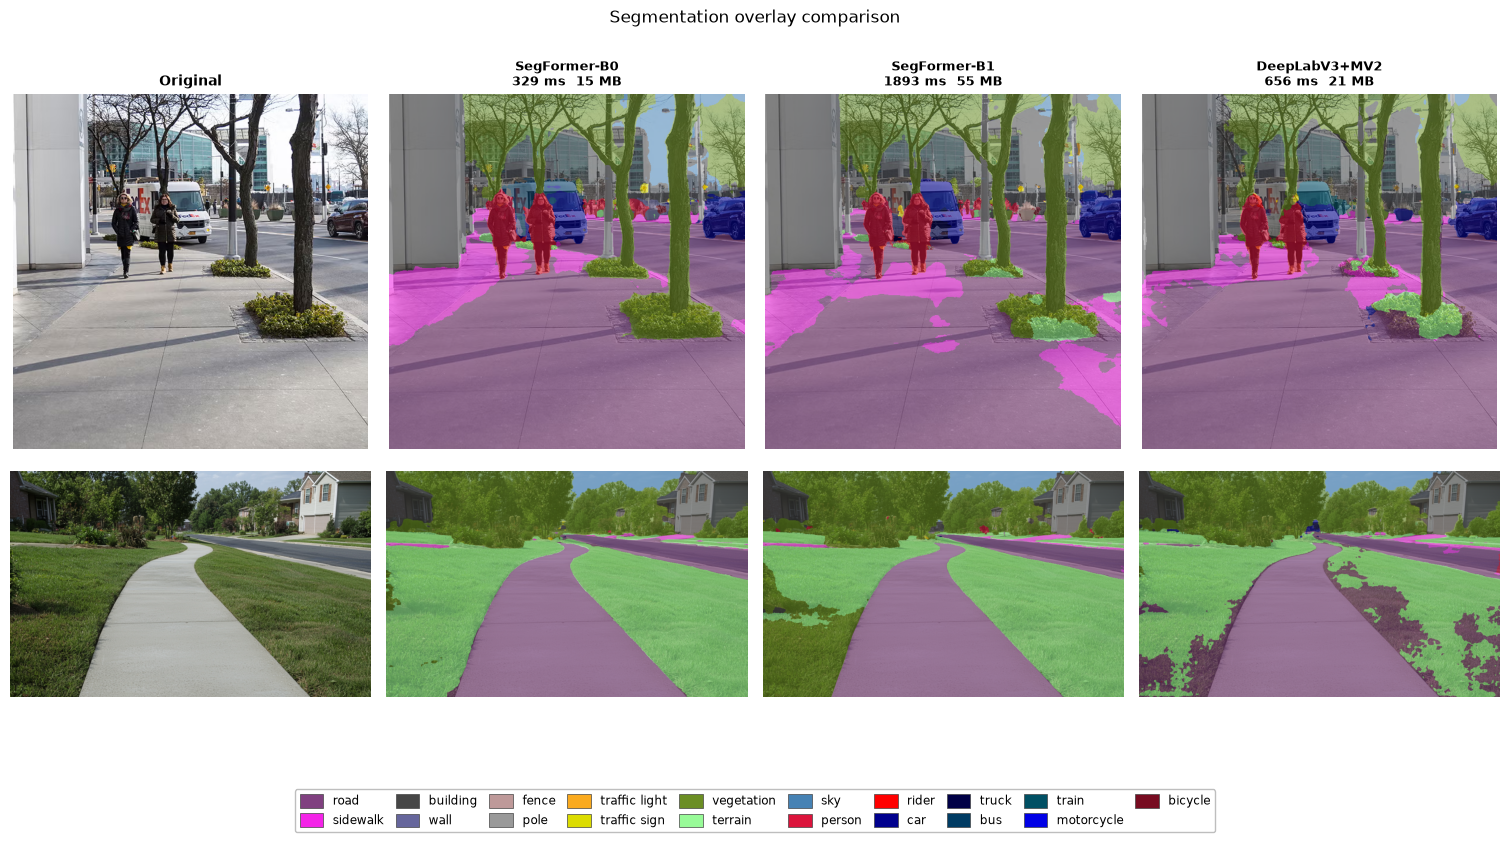

In [19]:
n_imgs   = min(4, len(image_paths))
n_models = len(MODELS)
fig, axes = plt.subplots(n_imgs, n_models + 1,
                          figsize=(3.8 * (n_models + 1), 3.8 * n_imgs))
if n_imgs == 1:
    axes = [axes]

axes[0][0].set_title('Original', fontsize=10, fontweight='bold')
for col, cfg in enumerate(MODELS):
    r = all_results[cfg['name']]
    axes[0][col + 1].set_title(
        f'{cfg["name"]}\n{r["avg_ms"]:.0f} ms  {r["size_mb"]:.0f} MB',
        fontsize=9, fontweight='bold')

for row in range(n_imgs):
    orig = all_results[MODELS[0]['name']]['originals'][row]
    axes[row][0].imshow(orig); axes[row][0].axis('off')
    axes[row][0].set_ylabel(os.path.basename(image_paths[row]), fontsize=7)

    for col, cfg in enumerate(MODELS):
        seg  = all_results[cfg['name']]['seg_maps'][row]
        ov   = make_overlay(orig, seg, cfg['colors'])
        axes[row][col + 1].imshow(ov); axes[row][col + 1].axis('off')

# Legend: colored square for every Cityscapes class
handles = [
    mpatches.Patch(
        facecolor=tuple(c / 255.0 for c in CITYSCAPES_COLORS[i]),
        edgecolor='#444', linewidth=0.5,
        label=CITYSCAPES_CLASSES[i],
    )
    for i in range(len(CITYSCAPES_CLASSES))
]
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=10,          # 10 classes per row → 2 rows for 19 classes
    fontsize=8.5,
    frameon=True,
    framealpha=0.95,
    edgecolor='#bbb',
    bbox_to_anchor=(0.5, -0.08),
    handlelength=2.0,
    handleheight=1.4,
    columnspacing=1.0,
)

plt.suptitle('Segmentation overlay comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 9. Path & obstacle masks per model

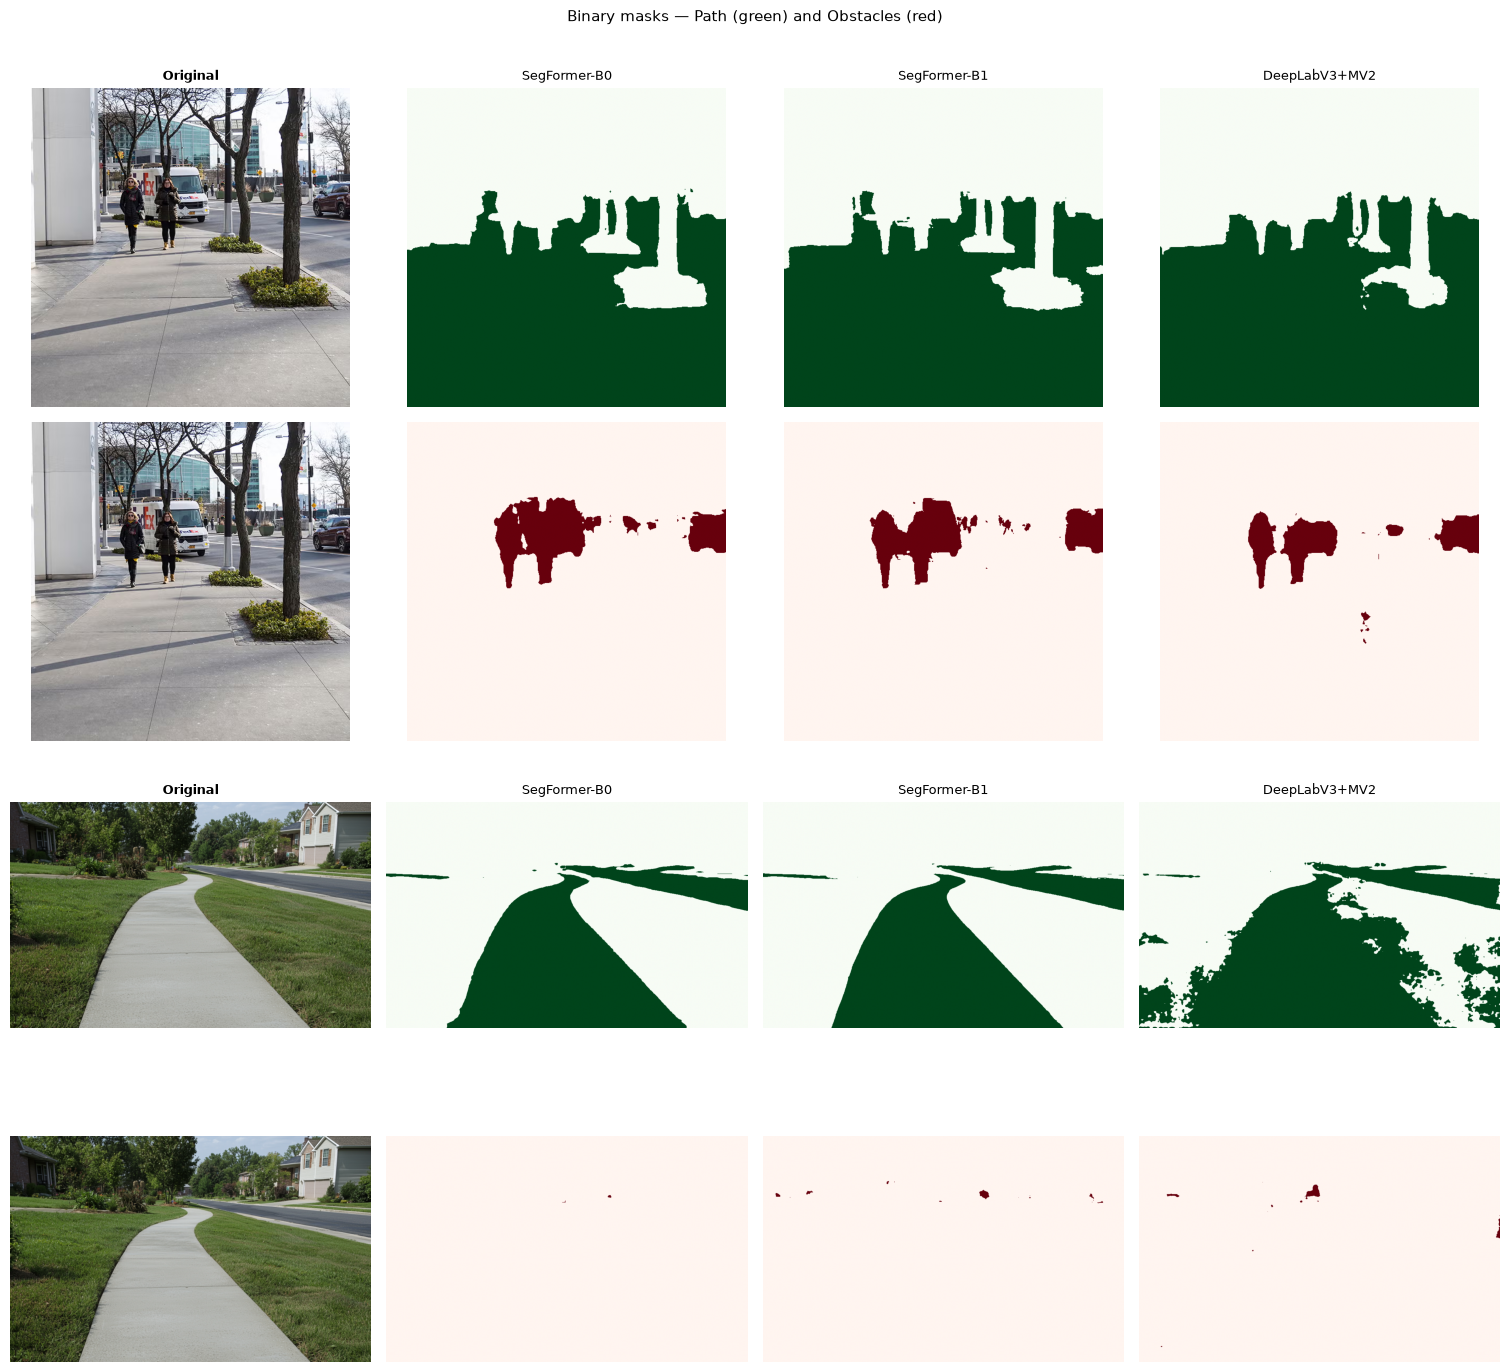

In [16]:
n_imgs = min(2, len(image_paths))
fig, axes = plt.subplots(n_imgs * 2, n_models + 1,
                          figsize=(3.8 * (n_models + 1), 3.5 * n_imgs * 2))
if n_imgs * 2 == 2:
    axes = [axes[0:1], axes[1:2]]   # keep 2-D indexing

row_labels = ['Path (road+sidewalk)', 'Obstacles']
for row_grp in range(n_imgs):
    base = row_grp * 2
    axes[base][0].set_title('Original', fontsize=9, fontweight='bold')
    orig = all_results[MODELS[0]['name']]['originals'][row_grp]
    for r in range(2):
        axes[base + r][0].imshow(orig); axes[base + r][0].axis('off')
        axes[base + r][0].set_ylabel(row_labels[r], fontsize=8)

    for col, cfg in enumerate(MODELS):
        seg = all_results[cfg['name']]['seg_maps'][row_grp]
        path_img = make_path_mask(seg, cfg['path_ids'])
        obs_img  = make_obs_mask(seg, cfg['obs_ids'])
        axes[base][col + 1].imshow(path_img, cmap='Greens', vmin=0, vmax=255)
        axes[base][col + 1].axis('off')
        axes[base][col + 1].set_title(cfg['name'], fontsize=9)
        axes[base + 1][col + 1].imshow(obs_img, cmap='Reds', vmin=0, vmax=255)
        axes[base + 1][col + 1].axis('off')

plt.suptitle('Binary masks — Path (green) and Obstacles (red)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 10. Benchmark summary table

In [17]:
hdr = f'{"Model":<18} {"Source":<26} {"Params":>8} {"Size":>8} {"mIoU":>6} {"ms/frame":>10} {"Sidewalk?":>10} {"Phone?":>8}'
print(hdr)
print('─' * len(hdr))

for cfg in MODELS:
    r     = all_results[cfg['name']]
    miou  = f'{cfg["paper_miou"]}' if cfg['paper_miou'] else '—'
    sw    = '✓' if cfg['path_ids'] else '✗'
    phone = '✓' if cfg['phone'] else '~'
    print(f'{cfg["name"]:<18} {cfg["source"]:<26} {cfg["params_m"]:>7.1f}M'
          f' {r["size_mb"]:>6.1f}MB {miou:>6} {r["avg_ms"]:>9.1f}ms {sw:>10} {phone:>8}')

Model              Source                       Params     Size   mIoU   ms/frame  Sidewalk?   Phone?
─────────────────────────────────────────────────────────────────────────────────────────────────────
SegFormer-B0       nvidia/segformer-b0 Cityscapes     3.7M   14.9MB   76.2     329.1ms          ✓        ✓
SegFormer-B1       nvidia/segformer-b1 Cityscapes    13.7M   54.7MB   78.5    1893.1ms          ✓        ~
DeepLabV3+MV2      VainF/DeepLabV3Plus-Pytorch     5.8M   20.9MB   72.0     656.5ms          ✓        ✓


## 11. Export best Cityscapes model to ONNX

SegFormer-B0 wins on size + sidewalk detection.
`onnx2tf -i segformer_b0_cityscapes.onnx -o tflite_out` converts it to TFLite.

In [18]:
ONNX_PATH = os.path.join(MODEL_DIR, 'segformer_b0_cityscapes.onnx')

_proc = AutoImageProcessor.from_pretrained('nvidia/segformer-b0-finetuned-cityscapes-512-1024')
_m    = AutoModelForSemanticSegmentation.from_pretrained(
    'nvidia/segformer-b0-finetuned-cityscapes-512-1024').cpu().eval()

dummy = torch.randn(1, 3, 512, 512)
torch.onnx.export(
    _m, dummy, ONNX_PATH,
    input_names=['pixel_values'],
    output_names=['logits'],
    dynamic_axes={'pixel_values': {0: 'batch', 2: 'height', 3: 'width'}},
    opset_version=14,
    dynamo=False,   # use legacy exporter — no onnxscript dependency
)
del _m

print(f'Saved: {ONNX_PATH}  ({os.path.getsize(ONNX_PATH) / 1e6:.1f} MB)')
print('Next step: onnx2tf -i segformer_b0_cityscapes.onnx -o tflite_out')

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

C:\Users\demat\AppData\Local\Temp\ipykernel_30628\2238165782.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
d:\code\Hackathon\26.06.2026\safecity\apps\ml\.venv\Lib\site-packages\transformers\integrations\sdpa_attention.py:77: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  is_causal = query.shape[2] > 1 and attention_mask is None and is_causal


OnnxExporterError: Module onnx is not installed!